  E0 (1).csv: 309 rijen (2025-08-15 → 2026-03-22)
  E0 (2).csv: 380 rijen (2024-08-16 → 2025-05-25)
  E0 (3).csv: 380 rijen (2023-08-11 → 2024-05-19)
  E0 (4).csv: 380 rijen (2022-08-05 → 2023-05-28)
  E0 (5).csv: 380 rijen (2021-08-13 → 2022-05-22)
  E0 (6).csv: 380 rijen (2020-09-12 → 2021-05-23)

Totaal odds: 2209 wedstrijden
Kalman:      2606 wedstrijden

Kalman kansen berekend voor 2606 wedstrijden
Gekoppeld:  2188 wedstrijden
Periode:    2020-09-12 → 2026-03-22
B365 gevuld:2188
PSH gevuld: 2072

  BET365 — Goals Kalman  (edge ≥ 5%)
  Wedstrijden beschikbaar: 2188
  Bets geplaatst:          1343
  Netto resultaat:         €-81.09
  ROI:                     -6.0%
  Win rate:                27.1%

  PINNACLE — Goals Kalman  (edge ≥ 5%)
  Wedstrijden beschikbaar: 2072
  Bets geplaatst:          1279
  Netto resultaat:         €-172.49
  ROI:                     -13.5%
  Win rate:                25.5%


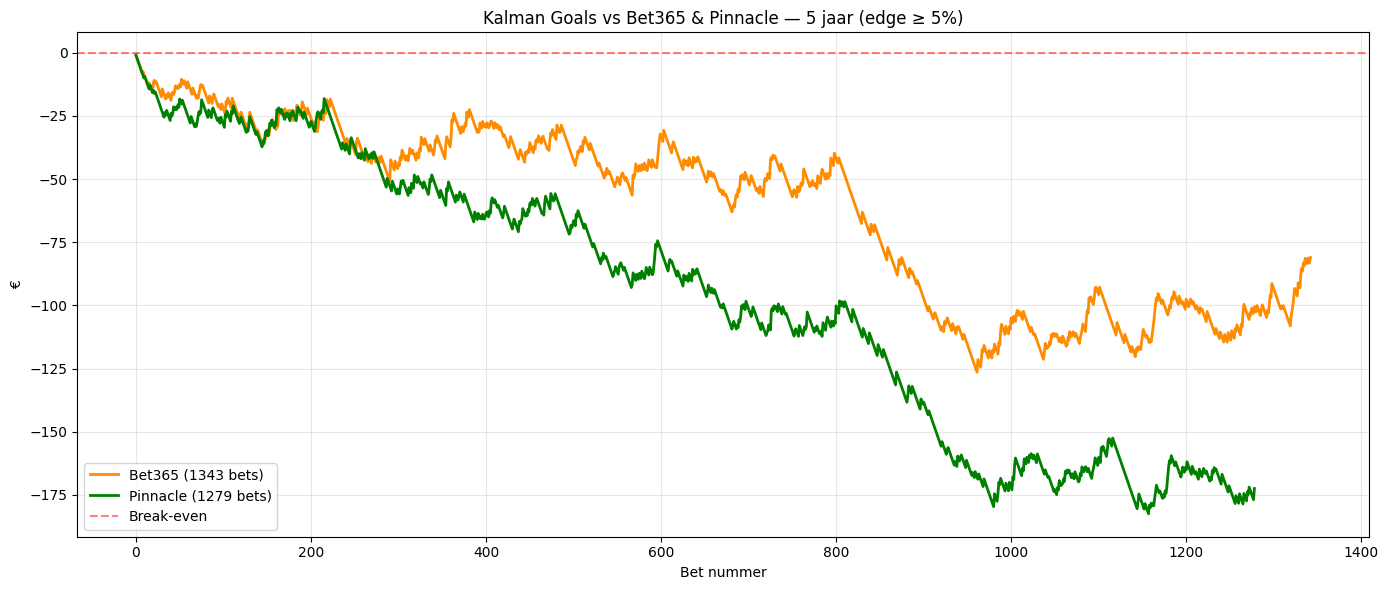


=== ROI BIJ VERSCHILLENDE DREMPELS ===
 Drempel | B365 bets  B365 ROI | Pinn bets  Pinn ROI
-------------------------------------------------------
    0.00 |      2188     -4.6% |      2072     -4.1%
    0.02 |      2058     -4.7% |      1963     -4.0%
    0.05 |      1343     -6.0% |      1279    -13.5%
    0.08 |       674    -11.8% |       632    -14.7%
    0.10 |       393    -14.0% |       384    -20.9%
    0.15 |        88     -1.7% |        82     -7.6%
    0.20 |        23     -8.9% |        21    +17.4%

=== ACCURACY ===
Kalman:   0.518
Bet365:   0.547


TypeError: '<' not supported between instances of 'float' and 'str'

In [1]:
"""
Kalman Betting Simulatie — Goals versie — Bet365 + Pinnacle (5 jaar)
=====================================================================
Input:
  - Kalman data/kalman_real_goals.csv
  - odds raw/E0*.csv  (2020 t/m 2025)
"""

import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from sklearn.metrics import accuracy_score, brier_score_loss

warnings.filterwarnings('ignore')

BASE_DIR = r"C:\Users\semwi\FPL-Core-Insights\data"
os.chdir(BASE_DIR)

# ══════════════════════════════════════════════════════════════════════════════
# STAP 1 — Data laden
# ══════════════════════════════════════════════════════════════════════════════
kalman = pd.read_csv(r"Kalman data\kalman_real_goals.csv")
kalman['date'] = pd.to_datetime(kalman['date'])

ODDS_TEAM_MAP = {
    "Man United":    "Manchester United",
    "Man City":      "Manchester City",
    "Tottenham":     "Tottenham Hotspur",
    "Newcastle":     "Newcastle United",
    "Brighton":      "Brighton & Hove Albion",
    "West Ham":      "West Ham United",
    "Leicester":     "Leicester City",
    "Ipswich":       "Ipswich Town",
    "Luton":         "Luton Town",
    "Wolves":        "Wolverhampton Wanderers",
    "Wolverhampton": "Wolverhampton Wanderers",
    "Nott'm Forest": "Nottingham Forest",
    "Leeds":         "Leeds United",
    "West Brom":     "West Bromwich Albion",
}

KALMAN_TEAM_MAP = {
    "Wolverhampton":          "Wolverhampton Wanderers",
    "Wolverhampton Wanderers":"Wolverhampton Wanderers",
}

# Laad alle odds bestanden vanaf 2020
odds_dfs = []
for path in sorted(glob.glob(os.path.join(BASE_DIR, r"odds raw\E0*.csv"))):
    df = pd.read_csv(path, encoding='latin-1')
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df = df[df['Date'] >= '2020-08-01']
    if len(df) > 0:
        odds_dfs.append(df)
        print(f"  {os.path.basename(path)}: {len(df)} rijen ({df['Date'].min().date()} → {df['Date'].max().date()})")

odds = pd.concat(odds_dfs, ignore_index=True)
odds['HomeTeam'] = odds['HomeTeam'].replace(ODDS_TEAM_MAP)
odds['AwayTeam'] = odds['AwayTeam'].replace(ODDS_TEAM_MAP)
odds['_date'] = odds['Date'].dt.date.astype(str)

print(f"\nTotaal odds: {len(odds)} wedstrijden")
print(f"Kalman:      {len(kalman)} wedstrijden")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 2 — Poisson kansen via Dixon-Coles (geen scaling — goals versie)
# ══════════════════════════════════════════════════════════════════════════════
def dixon_coles_tau(goals_h, goals_a, lambda_h, lambda_a, rho=-0.13):
    if goals_h == 0 and goals_a == 0:
        return 1 - lambda_h * lambda_a * rho
    elif goals_h == 1 and goals_a == 0:
        return 1 + lambda_a * rho
    elif goals_h == 0 and goals_a == 1:
        return 1 + lambda_h * rho
    elif goals_h == 1 and goals_a == 1:
        return 1 - rho
    return 1.0

def goals_to_probabilities(lambda_home, lambda_away, max_goals=8, rho=-0.13):
    # Geen scaling — goals zijn al in de juiste schaal
    lambda_home = max(lambda_home, 0.05)
    lambda_away = max(lambda_away, 0.05)
    prob_home = prob_draw = prob_away = 0.0
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = (poisson.pmf(i, lambda_home) *
                 poisson.pmf(j, lambda_away) *
                 dixon_coles_tau(i, j, lambda_home, lambda_away, rho))
            if i > j:    prob_home += p
            elif i == j: prob_draw += p
            else:        prob_away += p
    total = prob_home + prob_draw + prob_away
    return prob_home / total, prob_draw / total, prob_away / total

# ══════════════════════════════════════════════════════════════════════════════
# STAP 3 — Kalman kansen berekenen
# ══════════════════════════════════════════════════════════════════════════════
kalman_valid = kalman[kalman['kalman_goals_pred_home'].notna()].copy()
kalman_valid['home_team'] = kalman_valid['home_team'].replace(KALMAN_TEAM_MAP)
kalman_valid['away_team'] = kalman_valid['away_team'].replace(KALMAN_TEAM_MAP)

probs = kalman_valid.apply(
    lambda row: goals_to_probabilities(row['kalman_goals_pred_home'], row['kalman_goals_pred_away']),
    axis=1
)
kalman_valid['kalman_prob_home'] = [p[0] for p in probs]
kalman_valid['kalman_prob_draw'] = [p[1] for p in probs]
kalman_valid['kalman_prob_away'] = [p[2] for p in probs]
kalman_valid['_date'] = kalman_valid['date'].dt.date.astype(str)
print(f"\nKalman kansen berekend voor {len(kalman_valid)} wedstrijden")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 4 — Mergen Kalman + Odds
# ══════════════════════════════════════════════════════════════════════════════
merged = kalman_valid.merge(
    odds[['_date', 'HomeTeam', 'AwayTeam',
          'FTHG', 'FTAG',
          'B365H', 'B365D', 'B365A',
          'PSH',   'PSD',   'PSA']],
    left_on=['_date', 'home_team', 'away_team'],
    right_on=['_date', 'HomeTeam', 'AwayTeam'],
    how='inner'
).drop(columns=['HomeTeam', 'AwayTeam', '_date'])

merged['home_goals'] = merged['FTHG'].astype(float)
merged['away_goals'] = merged['FTAG'].astype(float)
merged = merged[merged['home_goals'].notna() & merged['away_goals'].notna()].copy()
merged['result'] = merged.apply(
    lambda r: 'H' if r['home_goals'] > r['away_goals'] else ('A' if r['home_goals'] < r['away_goals'] else 'D'),
    axis=1
)

# Odds → genormaliseerde kansen (marge eruit)
for bookie, cols in [('b365', ['B365H','B365D','B365A']), ('pinn', ['PSH','PSD','PSA'])]:
    h, d, a = cols
    merged[f'{bookie}_prob_home'] = 1 / merged[h]
    merged[f'{bookie}_prob_draw'] = 1 / merged[d]
    merged[f'{bookie}_prob_away'] = 1 / merged[a]
    total = merged[f'{bookie}_prob_home'] + merged[f'{bookie}_prob_draw'] + merged[f'{bookie}_prob_away']
    merged[f'{bookie}_prob_home'] /= total
    merged[f'{bookie}_prob_draw'] /= total
    merged[f'{bookie}_prob_away'] /= total

print(f"Gekoppeld:  {len(merged)} wedstrijden")
print(f"Periode:    {merged['date'].min().date()} → {merged['date'].max().date()}")
print(f"B365 gevuld:{merged['B365H'].notna().sum()}")
print(f"PSH gevuld: {merged['PSH'].notna().sum()}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 5 — Simulatie functie
# ══════════════════════════════════════════════════════════════════════════════
def simuleer(df, label, prob_h, prob_d, prob_a, odds_h, odds_d, odds_a, edge_threshold):
    sim = df[df[odds_h].notna()].copy()
    bet_results = []
    bankroll = 0.0
    bets = 0

    for _, row in sim.iterrows():
        edges = {
            'H': row['kalman_prob_home'] - row[prob_h],
            'D': row['kalman_prob_draw'] - row[prob_d],
            'A': row['kalman_prob_away'] - row[prob_a],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= edge_threshold:
            bets += 1
            bookie_odds = row[odds_h if best=='H' else odds_d if best=='D' else odds_a]
            if pd.isna(bookie_odds) or bookie_odds <= 1:
                continue
            profit = (bookie_odds - 1) if row['result'] == best else -1.0
            bankroll += profit
            bet_results.append({
                'match':      f"{row['home_team']} vs {row['away_team']}",
                'date':       str(row['date'].date()),
                'bet':        best,
                'result':     row['result'],
                'edge':       round(edges[best], 3),
                'odds':       round(bookie_odds, 2),
                'profit':     round(profit, 2),
                'cumulative': round(bankroll, 2),
                'won':        row['result'] == best,
            })

    results_df = pd.DataFrame(bet_results)
    roi = bankroll/bets*100 if bets > 0 else 0
    winrate = results_df['won'].mean()*100 if len(results_df) > 0 else 0

    print(f"\n{'='*55}")
    print(f"  {label}  (edge ≥ {edge_threshold*100:.0f}%)")
    print(f"{'='*55}")
    print(f"  Wedstrijden beschikbaar: {len(sim)}")
    print(f"  Bets geplaatst:          {bets}")
    print(f"  Netto resultaat:         €{bankroll:.2f}")
    print(f"  ROI:                     {roi:+.1f}%")
    print(f"  Win rate:                {winrate:.1f}%")

    return results_df

EDGE = 0.05

res_b365 = simuleer(merged, "BET365 — Goals Kalman",
    'b365_prob_home', 'b365_prob_draw', 'b365_prob_away',
    'B365H', 'B365D', 'B365A', EDGE)

res_pinn = simuleer(merged, "PINNACLE — Goals Kalman",
    'pinn_prob_home', 'pinn_prob_draw', 'pinn_prob_away',
    'PSH', 'PSD', 'PSA', EDGE)

# ══════════════════════════════════════════════════════════════════════════════
# STAP 6 — Visualisatie
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

if len(res_b365) > 0:
    ax.plot(range(len(res_b365)), res_b365['cumulative'], linewidth=2,
            color='darkorange', label=f'Bet365 ({len(res_b365)} bets)')
if len(res_pinn) > 0:
    ax.plot(range(len(res_pinn)), res_pinn['cumulative'], linewidth=2,
            color='green', label=f'Pinnacle ({len(res_pinn)} bets)')

ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='Break-even')
ax.set_title(f'Kalman Goals vs Bet365 & Pinnacle — 5 jaar (edge ≥ {EDGE*100:.0f}%)')
ax.set_xlabel('Bet nummer')
ax.set_ylabel('€')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kalman_goals_betting_5jaar.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# STAP 7 — ROI tabel bij verschillende drempels
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== ROI BIJ VERSCHILLENDE DREMPELS ===")
print(f"{'Drempel':>8} | {'B365 bets':>9} {'B365 ROI':>9} | {'Pinn bets':>9} {'Pinn ROI':>9}")
print("-" * 55)

for drempel in [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    row_vals = {}
    for bookie, ph, pd_, pa, oh, od, oa in [
        ('b365', 'b365_prob_home','b365_prob_draw','b365_prob_away','B365H','B365D','B365A'),
        ('pinn', 'pinn_prob_home','pinn_prob_draw','pinn_prob_away','PSH','PSD','PSA'),
    ]:
        winst = bets = 0
        for _, row in merged[merged[oh].notna()].iterrows():
            edges = {
                'H': row['kalman_prob_home'] - row[ph],
                'D': row['kalman_prob_draw'] - row[pd_],
                'A': row['kalman_prob_away'] - row[pa],
            }
            best = max(edges, key=edges.get)
            if edges[best] >= drempel:
                bets += 1
                bookie_odds = row[oh if best=='H' else od if best=='D' else oa]
                if pd.isna(bookie_odds) or bookie_odds <= 1:
                    continue
                winst += (bookie_odds - 1) if row['result'] == best else -1
        roi = winst/bets*100 if bets > 0 else 0
        row_vals[bookie] = (bets, roi)

    b_b, r_b = row_vals['b365']
    b_n, r_n = row_vals['pinn']
    print(f"{drempel:>8.2f} | {b_b:>9d} {r_b:>+8.1f}% | {b_n:>9d} {r_n:>+8.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 8 — Accuracy & Brier score
# ══════════════════════════════════════════════════════════════════════════════
merged['kalman_pred'] = merged[['kalman_prob_home','kalman_prob_draw','kalman_prob_away']].idxmax(axis=1)
merged['kalman_pred'] = merged['kalman_pred'].map({'kalman_prob_home':'H','kalman_prob_draw':'D','kalman_prob_away':'A'})
merged['b365_pred']   = merged[['b365_prob_home','b365_prob_draw','b365_prob_away']].idxmax(axis=1)
merged['b365_pred']   = merged['b365_pred'].map({'b365_prob_home':'H','b365_prob_draw':'D','b365_prob_away':'A'})
merged['pinn_pred']   = merged[['pinn_prob_home','pinn_prob_draw','pinn_prob_away']].idxmax(axis=1)
merged['pinn_pred']   = merged['pinn_pred'].map({'pinn_prob_home':'H','pinn_prob_draw':'D','pinn_prob_away':'A'})

print("\n=== ACCURACY ===")
print(f"Kalman:   {accuracy_score(merged['result'], merged['kalman_pred']):.3f}")
print(f"Bet365:   {accuracy_score(merged['result'], merged['b365_pred']):.3f}")
print(f"Pinnacle: {accuracy_score(merged['result'], merged['pinn_pred']):.3f}")

print("\n=== BRIER SCORE (lager = beter) ===")
print(f"{'':10s} {'Kalman':>8} {'Bet365':>8} {'Pinnacle':>8}")
for outcome, label in [('H','Thuis'), ('D','Gelijk'), ('A','Uit')]:
    actual_bin = (merged['result'] == outcome).astype(int)
    suf = 'home' if outcome=='H' else 'draw' if outcome=='D' else 'away'
    bk = brier_score_loss(actual_bin, merged[f'kalman_prob_{suf}'])
    bb = brier_score_loss(actual_bin, merged[f'b365_prob_{suf}'])
    bp = brier_score_loss(actual_bin, merged[f'pinn_prob_{suf}'])
    print(f"{label:10s} {bk:>8.3f} {bb:>8.3f} {bp:>8.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# STAP 9 — Random baseline
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== RANDOM BASELINE (1000x, Bet365 odds) ===")
random.seed(42)
random_rois = []
sim_rand = merged[merged['B365H'].notna()].copy()
for _ in range(1000):
    winst = 0
    for _, row in sim_rand.iterrows():
        bet = random.choice(['H', 'D', 'A'])
        bookie_odds = row['B365H' if bet=='H' else 'B365D' if bet=='D' else 'B365A']
        winst += (bookie_odds - 1) if row['result'] == bet else -1
    random_rois.append(winst / len(sim_rand) * 100)

p5  = np.percentile(random_rois, 2.5)
p95 = np.percentile(random_rois, 97.5)
model_roi = res_b365['profit'].sum()/len(res_b365)*100 if len(res_b365) > 0 else 0

print(f"Gemiddelde random ROI: {np.mean(random_rois):+.1f}%")
print(f"95% interval:         [{p5:+.1f}%, {p95:+.1f}%]")
print(f"Kalman Goals ROI:     {model_roi:+.1f}%")
if p5 < model_roi < p95:
    print("⚠️  Niet statistisch significant")
else:
    print("✅ Statistisch significant op 95% niveau")